## 00 — Data Inspection

Inspect raw MLOmics CSV files for **GS-BRCA** and **GS-COAD** (Top features).  
Verify shapes, data types, missing values, and sample alignment across modalities.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import json
from src.utils import set_seeds, load_config

In [2]:
set_seeds(42)
config = load_config('../config.yaml')
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. List Raw Files

In [3]:
for cancer in config['project']['cancer_types']:
    top_dir = os.path.join('..', config['paths']['raw_data'], cancer, 'Top')
    print(f"\n{'='*60}")
    print(f"{cancer}")
    print(f"{'='*60}")
    for f in sorted(os.listdir(top_dir)):
        size_mb = os.path.getsize(os.path.join(top_dir, f)) / 1e6
        ftype = 'LABEL' if 'label_num' in f else 'MODALITY'
        print(f"  [{ftype:>8s}] {f:<40s}  {size_mb:>7.1f} MB")


GS-BRCA
  [   LABEL] 54814634_BRCA_label_num.csv                   0.0 MB
  [MODALITY] BRCA_CNV_top.csv                             61.4 MB
  [MODALITY] BRCA_Methy_top.csv                           61.6 MB
  [MODALITY] BRCA_mRNA_top.csv                            61.3 MB
  [MODALITY] BRCA_miRNA_top.csv                            1.8 MB

GS-COAD
  [   LABEL] 54814562_COAD_label_num.csv                   0.0 MB
  [MODALITY] COAD_CNV_top.csv                             23.8 MB
  [MODALITY] COAD_Methy_top.csv                           23.8 MB
  [MODALITY] COAD_mRNA_top.csv                            23.8 MB
  [MODALITY] COAD_miRNA_top.csv                            1.0 MB


## 2. Helper Functions

In [4]:
def inspect_modality(filepath, modality_name):
    """Load, transpose, and report stats for one modality CSV."""
    df_raw = pd.read_csv(filepath, index_col=0)
    df = df_raw.T

    vals = df.values.astype(float)
    stats = {
        'modality': modality_name,
        'raw_shape': list(df_raw.shape),
        'transposed_shape': list(df.shape),
        'n_samples': df.shape[0],
        'n_features': df.shape[1],
        'dtype': str(df.dtypes.unique().tolist()),
        'nan_count': int(np.isnan(vals).sum()),
        'inf_count': int(np.isinf(vals).sum()),
        'min': float(np.nanmin(vals)),
        'max': float(np.nanmax(vals)),
        'mean': float(np.nanmean(vals)),
        'std': float(np.nanstd(vals)),
        'zero_var_features': int((df.std() == 0).sum()),
    }

    print(f"\n--- {modality_name} ---")
    print(f"  Raw shape (features x samples): {tuple(stats['raw_shape'])}")
    print(f"  Transposed shape (samples x features): {tuple(stats['transposed_shape'])}")
    print(f"  Sample IDs (first 5): {list(df.index[:5])}")
    print(f"  Feature names (first 5): {list(df.columns[:5])}")
    print(f"  Dtype: {stats['dtype']}")
    print(f"  NaN count: {stats['nan_count']}")
    print(f"  Inf count: {stats['inf_count']}")
    print(f"  Range: [{stats['min']:.4f}, {stats['max']:.4f}]")
    print(f"  Mean: {stats['mean']:.4f}  Std: {stats['std']:.4f}")
    print(f"  Zero-variance features: {stats['zero_var_features']}")

    return df, stats


def inspect_labels(top_dir, cancer_short):
    """Load and report label distribution."""
    label_files = glob.glob(os.path.join(top_dir, f'*_{cancer_short}_label_num.csv'))
    assert len(label_files) == 1, f"Expected 1 label file, found {len(label_files)}"

    labels = pd.read_csv(label_files[0])
    print(f"\n--- Labels ({os.path.basename(label_files[0])}) ---")
    print(f"  Shape: {labels.shape}")
    print(f"  Columns: {list(labels.columns)}")
    print(f"  Unique classes: {sorted(labels['Label'].unique())}")
    print(f"  Distribution:")
    for cls, count in labels['Label'].value_counts().sort_index().items():
        pct = count / len(labels) * 100
        print(f"    Class {cls}: {count:>4d}  ({pct:5.1f}%)")

    return labels


def plot_class_distribution(labels, cancer, save_dir):
    """Bar plot of subtype distribution, saved to results/plots/."""
    os.makedirs(save_dir, exist_ok=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    counts = labels['Label'].value_counts().sort_index()
    palette = sns.color_palette('Set2', len(counts))
    bars = ax.bar(counts.index.astype(str), counts.values, color=palette)

    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                str(count), ha='center', va='bottom', fontweight='bold')

    ax.set_xlabel('Subtype Label')
    ax.set_ylabel('Sample Count')
    ax.set_title(f'{cancer} — Subtype Distribution (n={len(labels)})')

    short = cancer.split('-')[1]
    save_path = os.path.join(save_dir, f'class_distribution_{short}.png')
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {save_path}")


def check_sample_alignment(modality_dfs, labels, cancer):
    """Check sample ID overlap across modalities and labels."""
    print(f"\n--- Sample Alignment ({cancer}) ---")

    sample_sets = {}
    for name, df in modality_dfs.items():
        sample_sets[name] = set(df.index)
        print(f"  {name:>6s}: {len(df.index)} samples")

    common = set.intersection(*sample_sets.values())
    union_ = set.union(*sample_sets.values())
    print(f"\n  Common samples (all modalities): {len(common)}")
    print(f"  Union of all samples: {len(union_)}")

    for name, s in sample_sets.items():
        others = set.union(*[v for k, v in sample_sets.items() if k != name])
        only_here = s - others
        if only_here:
            print(f" Samples ONLY in {name}: {len(only_here)}")

    first_mod = list(modality_dfs.values())[0]
    if len(labels) == len(first_mod):
        print(f" Label count matches sample count ({len(labels)})")
    else:
        print(f" Label count ({len(labels)}) != sample count ({len(first_mod)})")

    return {
        'common_samples': len(common),
        'union_samples': len(union_),
        'label_count': len(labels),
    }

## 3. GS-BRCA Inspection

In [5]:
brca_dir = os.path.join('..', config['paths']['raw_data'], 'GS-BRCA', 'Top')

expected_features = {
    'mRNA': config['modalities']['mrna']['feature_count'],
    'miRNA': config['modalities']['mirna']['feature_count'],
    'Methy': config['modalities']['methy']['feature_count'],
    'CNV': config['modalities']['cnv']['feature_count'],
}

brca_dfs = {}
brca_stats = {}

for mod_key, mod_name in [('mrna', 'mRNA'), ('mirna', 'miRNA'), ('methy', 'Methy'), ('cnv', 'CNV')]:
    pattern = config['modalities'][mod_key]['file_pattern'].format(cancer='BRCA')
    filepath = os.path.join(brca_dir, pattern)
    df, stats = inspect_modality(filepath, mod_name)
    brca_dfs[mod_name] = df
    brca_stats[mod_name] = stats

    expected = expected_features[mod_name]
    actual = df.shape[1]
    if actual != expected:
        print(f"  DISCREPANCY: config expects {expected} features, file has {actual}")
    else:
        print(f"  Feature count matches config ({expected})")


--- mRNA ---
  Raw shape (features x samples): (5000, 671)
  Transposed shape (samples x features): (671, 5000)
  Sample IDs (first 5): ['TCGA.3C.AAAU.01', 'TCGA.3C.AALI.01', 'TCGA.3C.AALJ.01', 'TCGA.3C.AALK.01', 'TCGA.5L.AAT0.01']
  Feature names (first 5): ['C1orf210', 'GPBP1L1', 'DEF8', 'ACSL5', 'TTN']
  Dtype: [dtype('float64')]
  NaN count: 0
  Inf count: 0
  Range: [-5.4609, 14.6276]
  Mean: -0.0000  Std: 0.9993
  Zero-variance features: 0
  Feature count matches config (5000)

--- miRNA ---
  Raw shape (features x samples): (366, 671)
  Transposed shape (samples x features): (671, 366)
  Sample IDs (first 5): ['TCGA.3C.AAAU.01', 'TCGA.3C.AALI.01', 'TCGA.3C.AALJ.01', 'TCGA.3C.AALK.01', 'TCGA.5L.AAT0.01']
  Feature names (first 5): ['hsa.let.7a.1', 'hsa.let.7a.2', 'hsa.let.7a.3', 'hsa.let.7b', 'hsa.let.7c']
  Dtype: [dtype('float64')]
  NaN count: 111386
  Inf count: 0
  Range: [-5.6181, 6.8901]
  Mean: 0.0000  Std: 0.9993
  Zero-variance features: 0
  Feature count matches confi


--- Labels (54814634_BRCA_label_num.csv) ---
  Shape: (671, 1)
  Columns: ['Label']
  Unique classes: [0, 1, 2, 3, 4]
  Distribution:
    Class 0:  353  ( 52.6%)
    Class 1:   42  (  6.3%)
    Class 2:  132  ( 19.7%)
    Class 3:   31  (  4.6%)
    Class 4:  113  ( 16.8%)


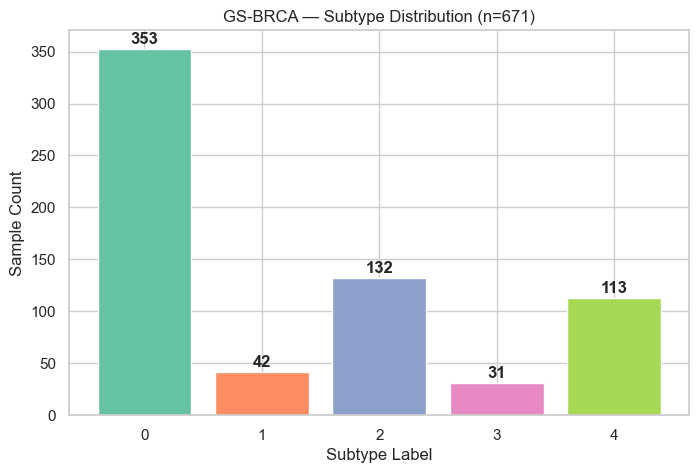

  Saved: ..\results\plots\class_distribution_BRCA.png


In [6]:
brca_labels = inspect_labels(brca_dir, 'BRCA')
plot_class_distribution(brca_labels, 'GS-BRCA',
                        os.path.join('..', 'results', 'plots'))

In [9]:
brca_alignment = check_sample_alignment(brca_dfs, brca_labels, 'GS-BRCA')


--- Sample Alignment (GS-BRCA) ---
    mRNA: 671 samples
   miRNA: 671 samples
   Methy: 671 samples
     CNV: 671 samples

  Common samples (all modalities): 671
  Union of all samples: 671
 Label count matches sample count (671)


## 4. GS-COAD Inspection

In [11]:
coad_dir = os.path.join('..', config['paths']['raw_data'], 'GS-COAD', 'Top')

coad_dfs = {}
coad_stats = {}

for mod_key, mod_name in [('mrna', 'mRNA'), ('mirna', 'miRNA'), ('methy', 'Methy'), ('cnv', 'CNV')]:
    pattern = config['modalities'][mod_key]['file_pattern'].format(cancer='COAD')
    filepath = os.path.join(coad_dir, pattern)
    df, stats = inspect_modality(filepath, mod_name)
    coad_dfs[mod_name] = df
    coad_stats[mod_name] = stats

    expected = expected_features[mod_name]
    actual = df.shape[1]
    if actual != expected:
        print(f"  DISCREPANCY: config expects {expected} features, file has {actual}")
    else:
        print(f"  Feature count matches config ({expected})")


--- mRNA ---
  Raw shape (features x samples): (5000, 260)
  Transposed shape (samples x features): (260, 5000)
  Sample IDs (first 5): ['TCGA.3L.AA1B.01', 'TCGA.4N.A93T.01', 'TCGA.4T.AA8H.01', 'TCGA.5M.AAT4.01', 'TCGA.5M.AAT6.01']
  Feature names (first 5): ['SERAC1', 'CD84', 'AKR1B10', 'TMEM38B', 'SLC2A11']
  Dtype: [dtype('float64')]
  NaN count: 0
  Inf count: 0
  Range: [-7.3228, 15.6704]
  Mean: 0.0000  Std: 0.9981
  Zero-variance features: 0
  Feature count matches config (5000)

--- miRNA ---
  Raw shape (features x samples): (200, 260)
  Transposed shape (samples x features): (260, 200)
  Sample IDs (first 5): ['TCGA.3L.AA1B.01', 'TCGA.4N.A93T.01', 'TCGA.4T.AA8H.01', 'TCGA.5M.AAT4.01', 'TCGA.5M.AAT6.01']
  Feature names (first 5): ['hsa.mir.196b', 'hsa.mir.147b', 'hsa.mir.149', 'hsa.mir.7.2', 'hsa.mir.338']
  Dtype: [dtype('float64')]
  NaN count: 0
  Inf count: 0
  Range: [-4.9025, 6.9618]
  Mean: 0.0000  Std: 0.9981
  Zero-variance features: 0
  DISCREPANCY: config expects 


--- Labels (54814562_COAD_label_num.csv) ---
  Shape: (260, 1)
  Columns: ['Label']
  Unique classes: [0, 1, 2, 3]
  Distribution:
    Class 0:  174  ( 66.9%)
    Class 1:   48  ( 18.5%)
    Class 2:   34  ( 13.1%)
    Class 3:    4  (  1.5%)


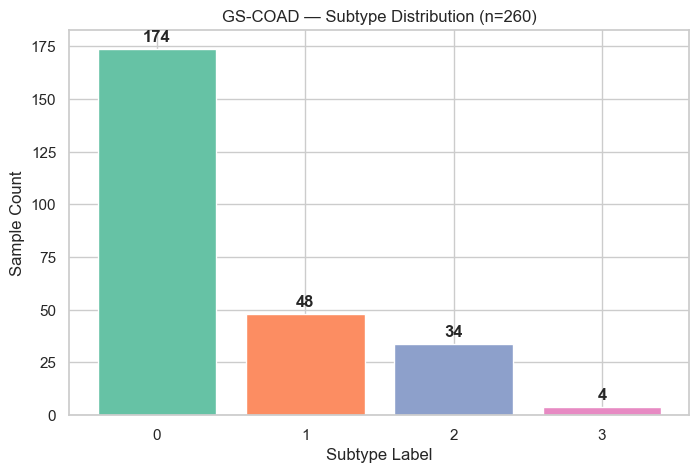

  Saved: ..\results\plots\class_distribution_COAD.png


In [12]:
coad_labels = inspect_labels(coad_dir, 'COAD')
plot_class_distribution(coad_labels, 'GS-COAD',
                        os.path.join('..', 'results', 'plots'))

In [13]:
coad_alignment = check_sample_alignment(coad_dfs, coad_labels, 'GS-COAD')


--- Sample Alignment (GS-COAD) ---
    mRNA: 260 samples
   miRNA: 260 samples
   Methy: 260 samples
     CNV: 260 samples

  Common samples (all modalities): 260
  Union of all samples: 260
 Label count matches sample count (260)


## 5. Summary

In [15]:
print(f"{'Cancer':<10} {'Modality':<10} {'Raw Shape':>16} {'Transposed':>16} {'NaN':>6} {'ZeroVar':>8} {'Common':>8}")
print('-' * 80)

for cancer, stats_dict, alignment in [
    ('GS-BRCA', brca_stats, brca_alignment),
    ('GS-COAD', coad_stats, coad_alignment),
]:
    for i, (mod, s) in enumerate(stats_dict.items()):
        raw = f"{s['raw_shape'][0]}x{s['raw_shape'][1]}"
        trans = f"{s['transposed_shape'][0]}x{s['transposed_shape'][1]}"
        common = str(alignment['common_samples']) if i == 0 else ''
        print(f"{cancer:<10} {mod:<10} {raw:>16} {trans:>16} {s['nan_count']:>6} {s['zero_var_features']:>8} {common:>8}")
    print()

# Save JSON report
def to_serializable(obj):
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj

report = {
    'timestamp': pd.Timestamp.now().isoformat(),
}
for cancer_name, stats_dict, alignment, labels_df in [
    ('GS-BRCA', brca_stats, brca_alignment, brca_labels),
    ('GS-COAD', coad_stats, coad_alignment, coad_labels),
]:
    report[cancer_name] = {
        'modalities': stats_dict,
        'alignment': alignment,
        'label_distribution': {str(k): int(v) for k, v in labels_df['Label'].value_counts().sort_index().items()},
    }

report_dir = os.path.join('..', 'results', 'qc')
os.makedirs(report_dir, exist_ok=True)
report_path = os.path.join(report_dir, 'data_inspection_report.json')

with open(report_path, 'w') as f:
    json.dump(report, f, indent=2, default=to_serializable)

print(f"\n Report saved: {report_path}")

Cancer     Modality          Raw Shape       Transposed    NaN  ZeroVar   Common
--------------------------------------------------------------------------------
GS-BRCA    mRNA               5000x671         671x5000      0        0      671
GS-BRCA    miRNA               366x671          671x366 111386        0         
GS-BRCA    Methy              5000x671         671x5000      0        0         
GS-BRCA    CNV                5000x671         671x5000      0        0         

GS-COAD    mRNA               5000x260         260x5000      0        0      260
GS-COAD    miRNA               200x260          260x200      0        0         
GS-COAD    Methy              5000x260         260x5000      0        0         
GS-COAD    CNV                5000x260         260x5000      0        0         


 Report saved: ..\results\qc\data_inspection_report.json
